Final testing script for not plain background experiments. Includes:
- Leave-one-out testing
- Thresholded testing
- MediaPipe testing

In [ ]:
# Mount Google Drive
!pip install mediapipe==0.10.9
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set up dataset path
os.chdir("drive/My Drive/")
spreadsheet_path = "Auslan Static Dataset Breakdown"
dataset_path = "AuslanStaticData"

Mounted at /content/drive


In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

# Authorise sheets access
gc = gspread.authorize(creds)

In [ ]:
import pandas as pd

worksheet = gc.open('Auslan Static Dataset Breakdown').sheet1

# Get all values from the worksheet
rows = worksheet.get_all_values()

# Convert to DataFrame with first row as column names
spreadsheet = pd.DataFrame(rows[1:], columns=rows[0])

print(spreadsheet)

     ID Subject         Date            Device        Filename Class Lighting  \
0     0    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_0_1.jpg     0  Natural   
1     1    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_1_1.jpg     1  Natural   
2     2    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_2_1.jpg     2  Natural   
3     3    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_3_1.jpg     3  Natural   
4     4    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_4_1.jpg     4  Natural   
...  ..     ...          ...               ...             ...   ...      ...   
4729       Nick  Apr 29 2025         iPhone 12  Nick_u_114.JPG     u  Natural   
4730       Nick  Apr 29 2025         iPhone 12  Nick_u_115.JPG     u  Natural   
4731       Nick  Apr 29 2025         iPhone 12  Nick_u_116.JPG     u  Natural   
4732       Nick  Apr 29 2025         iPhone 12  Nick_u_117.JPG     u  Natural   
4733       Nick  Apr 29 2025         iPhone 12  Nick_u_118.JPG     u  Natural   

     Light level           

In [ ]:
# Get list of files
file_list = os.listdir(dataset_path)

# Convert to DataFrame
drive_files = pd.DataFrame(file_list, columns=['Filename'])

set1 = set(drive_files['Filename'])
set2 = set(spreadsheet["Filename"])

# Find missing files
missing_in_df2 = set1 - set2  # Files in df1 but not in df2
missing_in_df1 = set2 - set1  # Files in df2 but not in df1

print("Files missing in Spreadsheet:", missing_in_df2)
print("Files missing in Drive folder:", missing_in_df1)

print(set1)
print(set2)

Files missing in Spreadsheet: {'Evelyn_1_58.jpeg'}
Files missing in Drive folder: set()
{'Evelyn_6_71.jpg', 'Nick_4_51.jpg', 'Nick_9_4.jpg', 'Nick_5_100.jpg', 'Luke_e_32.jpg', 'Daniel_7_33.jpg', 'Luke_8_5.jpg', 'Luke_w_6.jpg', 'Evelyn_e_16.jpg', 'Nick_a_25.jpg', 'Evelyn_u_74.jpg', 'Daniel_0_37.jpg', 'Daniel_e_11.jpg', 'Luke_v_4.jpg', 'Evelyn_4_8.jpg', 'Evelyn_6_58.jpeg', 'Evelyn_5_31.jpg', 'Nick_0_4.jpg', 'Nick_e_102.jpg', 'Luke_2_32.jpg', 'Evelyn_0_39.jpg', 'Daniel_a_1.jpg', 'Evelyn_2_23.jpg', 'Nick_1_22.jpg', 'Luke_2_4.jpg', 'Nick_0_18.jpg', 'Daniel_9_3.jpg', 'Nick_5_15.jpg', 'Luke_a_2.jpg', 'Evelyn_9_52.jpeg', 'Daniel_2_20.jpg', 'Evelyn_l_4.jpg', 'Nick_1_31.jpg', 'Evelyn_4_70.jpg', 'Daniel_a_46.jpg', 'Luke_o_2.jpg', 'Nick_8_18.jpg', 'Daniel_8_16.jpg', 'Daniel_3_17.jpg', 'Nick_8_61.jpg', 'Daniel_3_37.jpg', 'Luke_i_29.jpg', 'Nick_i_103.jpg', 'Luke_a_30.jpg', 'Evelyn_e_51.JPG', 'Daniel_3_38.jpg', 'Evelyn_6_68.jpg', 'Nick_s_1.jpg', 'Nick_a_46.jpg', 'Nick_8_110.jpg', 'Nick_4_90.jpg', 'Ni

In [ ]:
# Select independent testing variable

# Testing class
# Subject, Device, Light level, Lighting, Background, Skin Tone, Distance, Orientation, Away from body, Clothing
testing_class = "Background"

# Sub-class
# subject: Daniel, Evelyn, Luke, Nick
# device: Dell XPS 15 9050, Iphone
# light_level: Dark, Medium, Bright
# light_colour: Natural, Warm, Cold
# background: Plain, Somewhat/mostly plain, not_plain
# skin_tone: Brown, White, Tan
# distance: Close, Medium, Far
# orientation: Direct, Indirect
# body: Yes, No
# clothing: Light, Dark
# hand: Left, Right
independent_variable = "Not plain"

In [ ]:
# Create training and testing datasets that include and exclude specific images
import os
import pandas as pd
import shutil

vowel_numbers = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'e', 'i', 'o', 'u']

# Files excluding independent variable
spreadsheet_reduced = spreadsheet[spreadsheet['Class'].isin(vowel_numbers)]

images_without_var = spreadsheet_reduced[spreadsheet_reduced[testing_class] != independent_variable]
images_var = spreadsheet_reduced[spreadsheet_reduced[testing_class] == independent_variable]

filenames_without_var = images_without_var["Filename"]
filenames_var = images_var["Filename"]
all_filenames = spreadsheet_reduced["Filename"]

# Split data into training, validation, and testing sets
training_images_without_var = filenames_without_var.sample(frac=0.7)
remaining_images_without_var = filenames_without_var.drop(training_images_without_var.index)
validation_images_without_var = remaining_images_without_var.sample(frac=0.5)
testing_images_without_var = remaining_images_without_var.drop(validation_images_without_var.index)

training_images_with_var = filenames_var.sample(frac=0.7)
remaining_images_with_var = filenames_var.drop(training_images_with_var.index)
validation_images_with_var = remaining_images_with_var.sample(frac=0.5)

training_images_with_var_low = training_images_with_var.sample(frac=0.25)
remaining_images_with_var_low = training_images_with_var.drop(training_images_with_var_low.index)
validation_images_with_var_low = remaining_images_with_var_low.sample(frac=0.5)

training_images_with_var_medium = training_images_with_var.sample(frac=0.5)
remaining_images_with_var_medium = training_images_with_var.drop(training_images_with_var_medium.index)
validation_images_with_var_medium = remaining_images_with_var_medium.sample(frac=0.5)

training_images_with_var_high = training_images_with_var.sample(frac=0.75)
remaining_images_with_var_high = training_images_with_var.drop(training_images_with_var_high.index)
validation_images_with_var_high = remaining_images_with_var_high.sample(frac=0.5)

testing_images_only_var = remaining_images_with_var.drop(validation_images_with_var.index)
training_images_with_var = pd.concat([training_images_with_var, training_images_without_var], ignore_index=True)
training_images_with_var_low = pd.concat([training_images_with_var_low, training_images_without_var], ignore_index=True)
training_images_with_var_medium = pd.concat([training_images_with_var_medium, training_images_without_var], ignore_index=True)
training_images_with_var_high = pd.concat([training_images_with_var_high, training_images_without_var], ignore_index=True)

validation_images_with_var = pd.concat([validation_images_with_var, validation_images_without_var], ignore_index=True) # combined validation set with var and without var
validation_images_with_var_low = pd.concat([validation_images_with_var_low, validation_images_without_var], ignore_index=True) # combined validation set with var and without var
validation_images_with_var_medium = pd.concat([validation_images_with_var_medium, validation_images_without_var], ignore_index=True) # combined validation set with var and without var
validation_images_with_var_high = pd.concat([validation_images_with_var_high, validation_images_without_var], ignore_index=True) # combined validation set with var and without var

testing_images_mixed = pd.concat([testing_images_only_var, testing_images_without_var], ignore_index=True)

In [ ]:
# Extract class from filename
import re

def class_finder(filename):
    match = re.search(r'_(\w)_', filename)  # Extract the character between underscores
    if not match:
        raise ValueError("Filename format incorrect. Expected format: 'prefix_<char>_suffix'")

    extractFileClass = match.group(1)  # Get the matched class

    # Mapping for vowels
    class_map = {'a': 10, 'e': 11, 'i': 12, 'o': 13, 'u': 14}

    # Check if it's a digit
    if extractFileClass.isdigit():
        return int(extractFileClass)  # Convert string number to int
    elif extractFileClass in class_map:
        return class_map[extractFileClass]  # Map vowel to number
    else:
        raise ValueError(f"Unknown class: {extractFileClass}")  # Handle invalid cases

def label_generator(dataset_filenames):
    labels = []
    for filename in dataset_filenames:
        labels.append(class_finder(filename))
    return labels


In [ ]:
import tensorflow as tf

label_training_no_var = label_generator(training_images_without_var)
label_testing_no_var = label_generator(testing_images_without_var)
label_validation_no_var = label_generator(validation_images_without_var)

label_training_no_var = tf.keras.utils.to_categorical(label_training_no_var, num_classes=15)
label_testing_no_var = tf.keras.utils.to_categorical(label_testing_no_var, num_classes=15)
label_validation_no_var = tf.keras.utils.to_categorical(label_validation_no_var, num_classes=15)

print(training_images_without_var)
print(label_training_no_var)

label_training_var = label_generator(training_images_with_var)
label_testing_var = label_generator(testing_images_only_var)
label_validation_var = label_generator(validation_images_with_var)
label_testing_mixed = label_generator(testing_images_mixed)

label_training_var = tf.keras.utils.to_categorical(label_training_var, num_classes=15)
label_testing_var = tf.keras.utils.to_categorical(label_testing_var, num_classes=15)
label_validation_var = tf.keras.utils.to_categorical(label_validation_var, num_classes=15)
label_testing_mixed = tf.keras.utils.to_categorical(label_testing_mixed, num_classes=15)

label_training_var_low = label_generator(training_images_with_var_low)
label_validation_var_low = label_generator(validation_images_with_var_low)

label_training_var_medium = label_generator(training_images_with_var_medium)
label_validation_var_medium = label_generator(validation_images_with_var_medium)

label_training_var_high = label_generator(training_images_with_var_high)
label_validation_var_high = label_generator(validation_images_with_var_high)

label_training_var_low = tf.keras.utils.to_categorical(label_training_var_low, num_classes=15)
label_validation_var_low = tf.keras.utils.to_categorical(label_validation_var_low, num_classes=15)

label_training_var_medium = tf.keras.utils.to_categorical(label_training_var_medium, num_classes=15)
label_validation_var_medium = tf.keras.utils.to_categorical(label_validation_var_medium, num_classes=15)

label_training_var_high = tf.keras.utils.to_categorical(label_training_var_high, num_classes=15)
label_validation_var_high = tf.keras.utils.to_categorical(label_validation_var_high, num_classes=15)

3758       Luke_6_46.JPG
2058     Daniel_7_12.jpg
3251       Luke_i_11.jpg
4565     Evelyn_o_52.JPG
4555     Evelyn_i_57.JPG
              ...       
2167     Daniel_e_19.jpg
4389    Evelyn_1_54.jpeg
2693       Nick_i_48.jpg
3242       Luke_3_11.jpg
2217     Daniel_1_23.jpg
Name: Filename, Length: 2200, dtype: object
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [ ]:
# Create TF datasets from PD dataframes
def load_image(image_path):
    img = tf.io.read_file(os.path.join("AuslanStaticData", image_path.numpy().decode())) # Decode the image path from bytes to string
    img = tf.image.decode_jpeg(img, channels=3) # Decode the image
    img = tf.image.resize(img, [224, 224]) # Resize the image to your desired size
    img = tf.cast(img, tf.float32) # Cast the image to float32
    img = img / 255.0 # Normalize the pixel values to [0, 1]
    return img

def load_image_wrapper(image_path):
    img = tf.py_function(load_image, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Create training datasets
no_variable_training = tf.data.Dataset.from_tensor_slices((training_images_without_var.values, label_training_no_var)) # Create a dataset from the paths and labels
no_variable_training = no_variable_training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
no_variable_training = no_variable_training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

variable_training = tf.data.Dataset.from_tensor_slices((training_images_with_var.values, label_training_var)) # Create a dataset from the paths and labels
variable_training = variable_training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_training = variable_training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

variable_training_low = tf.data.Dataset.from_tensor_slices((training_images_with_var_low.values, label_training_var_low)) # Create a dataset from the paths and labels
variable_training_low = variable_training_low.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_training_low = variable_training_low.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

variable_training_medium = tf.data.Dataset.from_tensor_slices((training_images_with_var_medium.values, label_training_var_medium)) # Create a dataset from the paths and labels
variable_training_medium = variable_training_medium.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_training_medium = variable_training_medium.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

variable_training_high = tf.data.Dataset.from_tensor_slices((training_images_with_var_high.values, label_training_var_high)) # Create a dataset from the paths and labels
variable_training_high = variable_training_high.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_training_high = variable_training_high.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


# Create testing datasets
validation_var_dataset = tf.data.Dataset.from_tensor_slices((validation_images_with_var.values, label_validation_var))  # Replace validation_labels with appropriate label data
validation_var_dataset = validation_var_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_var_dataset = validation_var_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

validation_var_medium_dataset = tf.data.Dataset.from_tensor_slices((validation_images_with_var_medium.values, label_validation_var_medium))  # Replace validation_labels with appropriate label data
validation_var_medium_dataset = validation_var_medium_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_var_medium_dataset = validation_var_medium_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

validation_var_low_dataset = tf.data.Dataset.from_tensor_slices((validation_images_with_var_low.values, label_validation_var_low))  # Replace validation_labels with appropriate label data
validation_var_low_dataset = validation_var_low_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_var_low_dataset = validation_var_low_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


validation_var_high_dataset = tf.data.Dataset.from_tensor_slices((validation_images_with_var_high.values, label_validation_var_high))  # Replace validation_labels with appropriate label data
validation_var_high_dataset = validation_var_high_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_var_high_dataset = validation_var_high_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

validation_no_var_dataset = tf.data.Dataset.from_tensor_slices((validation_images_without_var.values, label_validation_no_var))  # Replace validation_labels with appropriate label data
validation_no_var_dataset = validation_no_var_dataset.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_no_var_dataset = validation_no_var_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

variable_testing = tf.data.Dataset.from_tensor_slices((testing_images_only_var.values, label_testing_var)) # Create a dataset from the paths and labels
variable_testing = variable_testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_testing = variable_testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

mixed_testing = tf.data.Dataset.from_tensor_slices((testing_images_mixed.values, label_testing_mixed)) # Create a dataset from the paths and labels
mixed_testing = mixed_testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
mixed_testing = mixed_testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

no_variable_testing = tf.data.Dataset.from_tensor_slices((testing_images_without_var.values, label_testing_no_var)) # Create a dataset from the paths and labels
no_variable_testing = no_variable_testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
no_variable_testing = no_variable_testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets
def add_random_noise_with_factor(image, label):
    # Generate noise with mean 0 and stddev 1 (or adjust as needed)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=1.0, dtype=tf.float32)

    # Generate a random noise_factor between 0.2 and 0.5
    noise_factor = tf.random.uniform(shape=[], minval=0.2, maxval=0.5)

    # Apply the noise with the random factor
    noisy_image = image + noise * noise_factor

    # Clip the pixel values to be within the valid range [0, 1]
    noisy_image = tf.clip_by_value(noisy_image, clip_value_min=0.0, clip_value_max=1.0)

    return noisy_image, label

var_flip_dataset = variable_training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
var_brightness_dataset = variable_training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
var_contrast_dataset = variable_training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
var_saturation_dataset = variable_training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
var_noise_dataset = variable_training.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

var_flip_dataset_low = variable_training_low.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
var_brightness_dataset_low = variable_training_low.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
var_contrast_dataset_low = variable_training_low.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
var_saturation_dataset_low = variable_training_low.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
var_noise_dataset_low = variable_training_low.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

var_flip_dataset_medium = variable_training_medium.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
var_brightness_dataset_medium = variable_training_medium.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
var_contrast_dataset_medium = variable_training_medium.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
var_saturation_dataset_medium = variable_training_medium.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
var_noise_dataset_medium = variable_training_medium.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

var_flip_dataset_high = variable_training_high.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
var_brightness_dataset_high = variable_training_high.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
var_contrast_dataset_high = variable_training_high.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
var_saturation_dataset_high = variable_training_high.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
var_noise_dataset_high = variable_training_high.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

no_var_flip_dataset = no_variable_training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
no_var_brightness_dataset = no_variable_training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.1), label))
no_var_contrast_dataset = no_variable_training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
no_var_saturation_dataset = no_variable_training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
no_var_noise_dataset = no_variable_training.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)

aug_no_var_training = tf.data.Dataset.sample_from_datasets([no_variable_training, no_var_flip_dataset, no_var_noise_dataset, no_var_brightness_dataset, no_var_contrast_dataset, no_var_saturation_dataset])
aug_var_training = tf.data.Dataset.sample_from_datasets([variable_training, var_flip_dataset, var_noise_dataset, var_brightness_dataset, var_contrast_dataset, var_saturation_dataset])
aug_var_low_training = tf.data.Dataset.sample_from_datasets([variable_training_low, var_flip_dataset_low, var_noise_dataset_low, var_brightness_dataset_low, var_contrast_dataset_low, var_saturation_dataset_low])
aug_var_medium_training = tf.data.Dataset.sample_from_datasets([variable_training_medium, var_flip_dataset_medium, var_noise_dataset_medium, var_brightness_dataset_medium, var_contrast_dataset_medium, var_saturation_dataset_medium])
aug_var_high_training = tf.data.Dataset.sample_from_datasets([variable_training_high, var_flip_dataset_high, var_noise_dataset_high, var_brightness_dataset_high, var_contrast_dataset_high, var_saturation_dataset_high])

A. Surmenok, keras\_lr\_finder, GitHub repository. Available: https://github.com/surmenok/keras\_lr\_finder. Accessed: May 03, 2025.

In [ ]:
from matplotlib import pyplot as plt
import math
from keras.callbacks import LambdaCallback
import keras.backend as K
import numpy as np

import numpy as np

def set_value(x, value):
    value = np.asarray(value, dtype=x.dtype)  # Use x.dtype instead of x.dtype.name
    x.assign(value)

class LRFinder:
    """
    Plots the change of the loss function of a Keras model when the learning rate is exponentially increasing.
    See for details:
    https://towardsdatascience.com/estimating-optimal-learning-rate-for-a-deep-neural-network-ce32f2556ce0
    """

    def __init__(self, model):
        self.model = model
        self.losses = []
        self.lrs = []
        self.best_loss = 1e9

    def on_batch_end(self, batch, logs):
        # Log the learning rate
        lr = K.get_value(self.model.optimizer.learning_rate)
        self.lrs.append(lr)

        # Log the loss
        loss = logs['loss']
        self.losses.append(loss)

        # Check whether the loss got too large or NaN
        if batch > 5 and (math.isnan(loss) or loss > self.best_loss * 4):
            self.model.stop_training = True
            return

        if loss < self.best_loss:
            self.best_loss = loss

        # Increase the learning rate for the next batch
        lr *= self.lr_mult
        set_value(self.model.optimizer.learning_rate, lr)

    def find(self, x_train, y_train, start_lr, end_lr, batch_size=64, epochs=1, **kw_fit):
        # If x_train contains data for multiple inputs, use length of the first input.
        # Assumption: the first element in the list is single input; NOT a list of inputs.
        N = x_train[0].shape[0] if isinstance(x_train, list) else x_train.shape[0]

        # Compute number of batches and LR multiplier
        num_batches = epochs * N / batch_size
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(num_batches))
        # Save weights into a file
        initial_weights = self.model.get_weights()

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.lr)

        # Set the initial learning rate
        K.set_value(self.model.optimizer.lr, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch, logs: self.on_batch_end(batch, logs))

        self.model.fit(x_train, y_train,
                       batch_size=batch_size, epochs=epochs,
                       callbacks=[callback],
                       **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.set_weights(initial_weights)

        # Restore the original learning rate
        K.set_value(self.model.optimizer.lr, original_lr)

    def find_generator(self, generator, start_lr, end_lr, epochs=1, steps_per_epoch=None, **kw_fit):
        if steps_per_epoch is None:
            try:
                steps_per_epoch = len(generator)
            except (ValueError, NotImplementedError) as e:
                raise e('`steps_per_epoch=None` is only valid for a'
                        ' generator based on the '
                        '`keras.utils.Sequence`'
                        ' class. Please specify `steps_per_epoch` '
                        'or use the `keras.utils.Sequence` class.')
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(epochs * steps_per_epoch))

        # Save weights into a file
        initial_weights = self.model.get_weights()

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.learning_rate)

        # Set the initial learning rate
        set_value(self.model.optimizer.learning_rate, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch,
                                                      logs: self.on_batch_end(batch, logs))

        self.model.fit(generator,
                                 epochs=epochs,
                                 steps_per_epoch=steps_per_epoch,
                                 callbacks=[callback],
                                 **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.set_weights(initial_weights)

        # Restore the original learning rate
        set_value(self.model.optimizer.learning_rate, original_lr)

    def plot_loss(self, n_skip_beginning=10, n_skip_end=5, x_scale='log'):
        """
        Plots the loss.
        Parameters:
            n_skip_beginning - number of batches to skip on the left.
            n_skip_end - number of batches to skip on the right.
        """
        plt.ylabel("loss")
        plt.xlabel("learning rate (log scale)")
        plt.plot(self.lrs[n_skip_beginning:-n_skip_end], self.losses[n_skip_beginning:-n_skip_end])
        plt.xscale(x_scale)
        plt.show()

    def plot_loss_change(self, sma=1, n_skip_beginning=10, n_skip_end=5, y_lim=(-0.01, 0.01)):
        """
        Plots rate of change of the loss function.
        Parameters:
            sma - number of batches for simple moving average to smooth out the curve.
            n_skip_beginning - number of batches to skip on the left.
            n_skip_end - number of batches to skip on the right.
            y_lim - limits for the y axis.
        """
        derivatives = self.get_derivatives(sma)[n_skip_beginning:-n_skip_end]
        lrs = self.lrs[n_skip_beginning:-n_skip_end]
        plt.ylabel("rate of loss change")
        plt.xlabel("learning rate (log scale)")
        plt.plot(lrs, derivatives)
        plt.xscale('log')
        plt.ylim(y_lim)
        plt.show()

    def get_derivatives(self, sma):
        assert sma >= 1
        derivatives = [0] * sma
        for i in range(sma, len(self.lrs)):
            derivatives.append((self.losses[i] - self.losses[i - sma]) / sma)
        return derivatives

    def get_best_lr(self, sma, n_skip_beginning=10, n_skip_end=5):
        derivatives = self.get_derivatives(sma)
        best_der_idx = np.argmin(derivatives[n_skip_beginning:-n_skip_end])
        return self.lrs[n_skip_beginning:-n_skip_end][best_der_idx]

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 244s 484ms/step - accuracy: 0.0690 - loss: 3.8324
Epoch 2/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 156ms/step - accuracy: 0.0779 - loss: 3.7094
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.1863 - loss: 3.2456
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.5181 - loss: 2.1304
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 157ms/step - accuracy: 0.7287 - loss: 1.4497
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.7083 - loss: 1.4357
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.4100 - loss: 2.2923
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 157ms/step - accuracy: 0.0821 - loss: 2.9864
Epoch 9/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.0788 - loss: 3.1929
Epoch 10/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 69s 152ms/step - accuracy: 0.0768 - loss: 2.9595


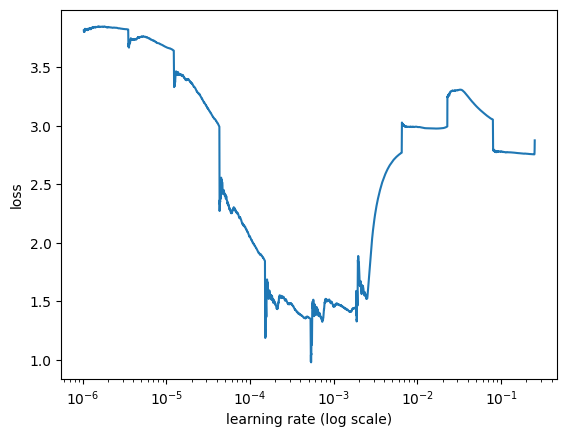

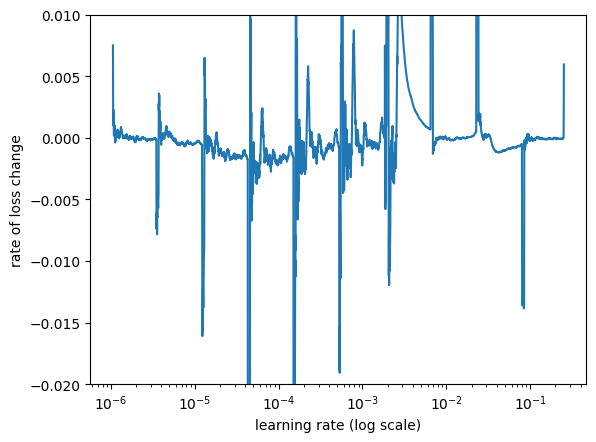

4.3206433e-05


In [ ]:
# Find optimal learning rate
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
# Unfreeze the last few convolutional layers
base_model.trainable = True

# Freeze most of the base model
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Define model with its own base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

import numpy as np
K = tf.keras.backend

BATCH = 32


STEPS_PER_EPOCH = np.ceil(14585 / BATCH)
STEPS_PER_EPOCH = int(STEPS_PER_EPOCH)
lr_finder = LRFinder(model)
lr_finder.find_generator(aug_no_var_training, start_lr=1e-6, end_lr=1, epochs=10,
                         steps_per_epoch=STEPS_PER_EPOCH)

lr_finder.plot_loss()
lr_finder.plot_loss_change(sma=20, n_skip_beginning=20, n_skip_end=5, y_lim=(-0.02, 0.01))

best_lr = lr_finder.get_best_lr(sma=20)

# Setting it as our model's LR through Keras Backend
set_value(model.optimizer.learning_rate, best_lr)
print(best_lr)

In [ ]:
# Perform thresholded and original leave one out tests

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model_no_var = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_no_var.trainable = True

# Freeze most of the base model
for layer in base_model_no_var.layers[:-4]:
    layer.trainable = False

# Define model_no_var with its own base model
model_no_var = models.Sequential([
    base_model_no_var,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate = float(best_lr)

optimizer_no_var = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_no_var.compile(
    optimizer=optimizer_no_var,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_no_var = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_no_var.fit(aug_no_var_training, epochs=50, batch_size=32,validation_data=validation_no_var_dataset, callbacks=[es_no_var])

# Repeat for variable and thresholded models
base_model_var = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_var.trainable = True

for layer in base_model_var.layers[:-4]:
    layer.trainable = False

model_var = models.Sequential([
    base_model_var,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate = float(best_lr)

optimizer_var = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_var.compile(
    optimizer=optimizer_var,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_var = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_var.fit(aug_var_training, epochs=50, batch_size=32,validation_data=validation_var_dataset, callbacks=[es_var])

base_model_var_low = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_var_low.trainable = True

for layer in base_model_var_low.layers[:-4]:
    layer.trainable = False

model_var_low = models.Sequential([
    base_model_var_low,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate = float(best_lr)

optimizer_var_low = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_var_low.compile(
    optimizer=optimizer_var_low,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_var_low = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_var_low.fit(aug_var_low_training, epochs=50, batch_size=32,validation_data=validation_var_low_dataset, callbacks=[es_var_low])

base_model_var_high = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_var_high.trainable = True

for layer in base_model_var_high.layers[:-4]:
    layer.trainable = False

model_var_high = models.Sequential([
    base_model_var_high,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate_high = float(best_lr)

optimizer_var_high = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_var_high.compile(
    optimizer=optimizer_var_high,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_var_high = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_var_high.fit(aug_var_high_training, epochs=50, batch_size=32,validation_data=validation_var_high_dataset, callbacks=[es_var_high])

base_model_var_medium = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_var_medium.trainable = True

for layer in base_model_var_medium.layers[:-4]:
    layer.trainable = False

model_var_medium = models.Sequential([
    base_model_var_medium,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate_medium = float(best_lr)

optimizer_var_medium = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model_var_medium.compile(
    optimizer=optimizer_var_medium,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_var_medium = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_var_medium.fit(aug_var_medium_training, epochs=50, batch_size=32,validation_data=validation_var_medium_dataset, callbacks=[es_var_medium])


Epoch 1/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 88s 194ms/step - accuracy: 0.1221 - loss: 3.5470 - val_accuracy: 0.3983 - val_loss: 2.4029
Epoch 2/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 74s 179ms/step - accuracy: 0.4715 - loss: 2.2021 - val_accuracy: 0.6949 - val_loss: 1.5074
Epoch 3/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 74s 179ms/step - accuracy: 0.7113 - loss: 1.5227 - val_accuracy: 0.7352 - val_loss: 1.2741
Epoch 4/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 74s 179ms/step - accuracy: 0.8248 - loss: 1.1816 - val_accuracy: 0.7691 - val_loss: 1.1979
Epoch 5/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 74s 179ms/step - accuracy: 0.8594 - loss: 1.0397 - val_accuracy: 0.7712 - val_loss: 1.2039
Epoch 6/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 75s 180ms/step - accuracy: 0.8926 - loss: 0.9260 - val_accuracy: 0.7924 - val_loss: 1.1642
Epoch 7/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 74s 179ms/step - accuracy: 0.9069 - loss: 0.8583 - val_accuracy: 0.7775 - val_loss: 1.1624
Epoch 8/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 74s 180ms/step - accuracy: 0.8938 - loss: 0

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_var_var = model_var.predict(variable_testing, verbose=1)
pred_var_novar = model_var.predict(no_variable_testing, verbose=1)
pred_var_mixed = model_var.predict(mixed_testing, verbose=1)

pred_novar_var = model_no_var.predict(variable_testing, verbose=1)
pred_novar_novar = model_no_var.predict(no_variable_testing, verbose=1)
pred_novar_mixed = model_no_var.predict(mixed_testing, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_var_var_labels = np.argmax(pred_var_var, axis=1)
pred_var_novar_labels = np.argmax(pred_var_novar, axis=1)
pred_var_mixed_labels = np.argmax(pred_var_mixed, axis=1)
pred_novar_var_labels = np.argmax(pred_novar_var, axis=1)
pred_novar_novar_labels = np.argmax(pred_novar_novar, axis=1)
pred_novar_mixed_labels = np.argmax(pred_novar_mixed, axis=1)

# Get the true labels from the test set generator
pred_var_var_true = np.concatenate([y.numpy() for _, y in variable_testing.unbatch()])
pred_var_novar_true = np.concatenate([y.numpy() for _, y in no_variable_testing.unbatch()])
pred_var_mixed_true = np.concatenate([y.numpy() for _, y in mixed_testing.unbatch()])

pred_novar_var_true = np.concatenate([y.numpy() for _, y in variable_testing.unbatch()])
pred_novar_novar_true = np.concatenate([y.numpy() for _, y in no_variable_testing.unbatch()])
pred_novar_mixed_true = np.concatenate([y.numpy() for _, y in mixed_testing.unbatch()])

# Reshape into (N, 36) where N is inferred
pred_var_var_true = pred_var_var_true.reshape(-1, 15)
pred_var_novar_true = pred_var_novar_true.reshape(-1, 15)
pred_var_mixed_true = pred_var_mixed_true.reshape(-1, 15)
pred_novar_var_true = pred_novar_var_true.reshape(-1, 15)
pred_novar_novar_true = pred_novar_novar_true.reshape(-1, 15)
pred_novar_mixed_true = pred_novar_mixed_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_var_var_true = np.argmax(pred_var_var_true, axis=1)
pred_var_novar_true = np.argmax(pred_var_novar_true, axis=1)
pred_var_mixed_true = np.argmax(pred_var_mixed_true, axis=1)
pred_novar_var_true = np.argmax(pred_novar_var_true, axis=1)
pred_novar_novar_true = np.argmax(pred_novar_novar_true, axis=1)
pred_novar_mixed_true = np.argmax(pred_novar_mixed_true, axis=1)

# Generate the confusion matrix
cm_var_var = confusion_matrix(pred_var_var_true, pred_var_var_labels)
cm_var_novar = confusion_matrix(pred_var_novar_true, pred_var_novar_labels)
cm_var_mixed = confusion_matrix(pred_var_mixed_true, pred_var_mixed_labels)
cm_novar_var = confusion_matrix(pred_novar_var_true, pred_novar_var_labels)
cm_novar_novar = confusion_matrix(pred_novar_novar_true, pred_novar_novar_labels)
cm_novar_mixed = confusion_matrix(pred_novar_mixed_true, pred_novar_mixed_labels)

# Predict on the test sets using additional models
pred_var_low_var = model_var_low.predict(variable_testing, verbose=1)
pred_var_low_novar = model_var_low.predict(no_variable_testing, verbose=1)
pred_var_low_mixed = model_var_low.predict(mixed_testing, verbose=1)

pred_var_medium_var = model_var_medium.predict(variable_testing, verbose=1)
pred_var_medium_novar = model_var_medium.predict(no_variable_testing, verbose=1)
pred_var_medium_mixed = model_var_medium.predict(mixed_testing, verbose=1)

pred_var_high_var = model_var_high.predict(variable_testing, verbose=1)
pred_var_high_novar = model_var_high.predict(no_variable_testing, verbose=1)
pred_var_high_mixed = model_var_high.predict(mixed_testing, verbose=1)

# Get predicted class labels
pred_var_low_var_labels = np.argmax(pred_var_low_var, axis=1)
pred_var_low_novar_labels = np.argmax(pred_var_low_novar, axis=1)
pred_var_low_mixed_labels = np.argmax(pred_var_low_mixed, axis=1)

pred_var_medium_var_labels = np.argmax(pred_var_medium_var, axis=1)
pred_var_medium_novar_labels = np.argmax(pred_var_medium_novar, axis=1)
pred_var_medium_mixed_labels = np.argmax(pred_var_medium_mixed, axis=1)

pred_var_high_var_labels = np.argmax(pred_var_high_var, axis=1)
pred_var_high_novar_labels = np.argmax(pred_var_high_novar, axis=1)
pred_var_high_mixed_labels = np.argmax(pred_var_high_mixed, axis=1)

# Generate the confusion matrices
cm_var_low_var = confusion_matrix(pred_var_var_true, pred_var_low_var_labels)
cm_var_low_novar = confusion_matrix(pred_var_novar_true, pred_var_low_novar_labels)
cm_var_low_mixed = confusion_matrix(pred_var_mixed_true, pred_var_low_mixed_labels)

cm_var_medium_var = confusion_matrix(pred_var_var_true, pred_var_medium_var_labels)
cm_var_medium_novar = confusion_matrix(pred_var_novar_true, pred_var_medium_novar_labels)
cm_var_medium_mixed = confusion_matrix(pred_var_mixed_true, pred_var_medium_mixed_labels)

cm_var_high_var = confusion_matrix(pred_var_var_true, pred_var_high_var_labels)
cm_var_high_novar = confusion_matrix(pred_var_novar_true, pred_var_high_novar_labels)
cm_var_high_mixed = confusion_matrix(pred_var_mixed_true, pred_var_high_mixed_labels)

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 778ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 490ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 456ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step


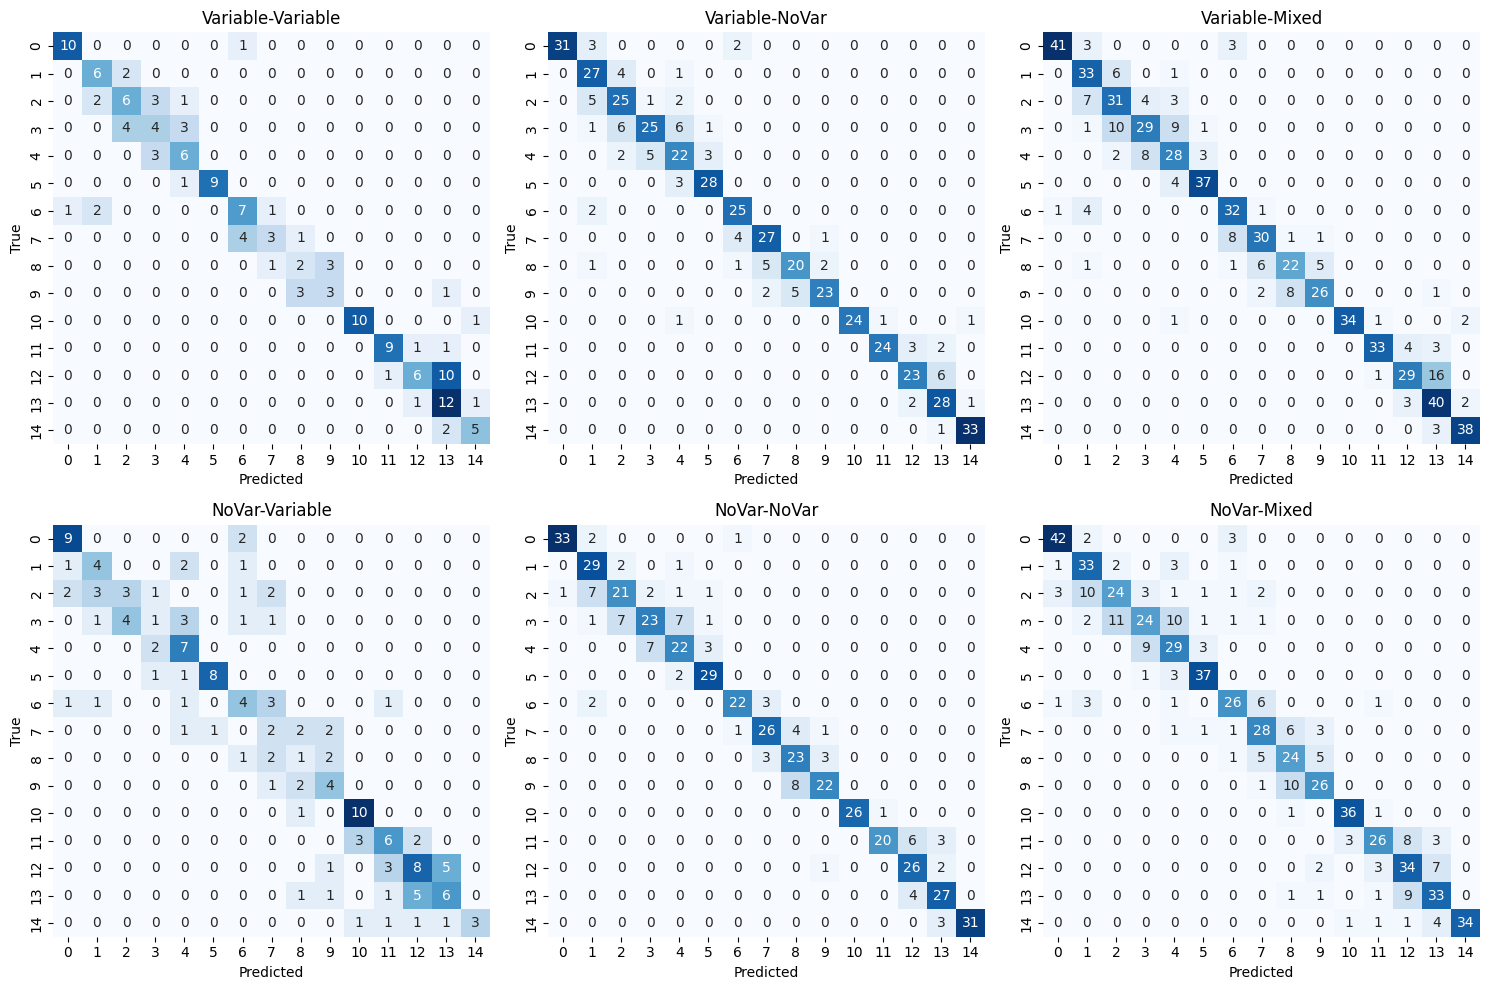

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_var_var, cm_var_novar, cm_var_mixed,
                      cm_novar_var, cm_novar_novar, cm_novar_mixed]
titles = ['Variable-Variable', 'Variable-NoVar', 'Variable-Mixed',
          'NoVar-Variable', 'NoVar-NoVar', 'NoVar-Mixed']

# Create a 2x3 grid for plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loop over each subplot and confusion matrix to plot
for ax, cm, title in zip(axes.flatten(), confusion_matrices, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=[str(i) for i in range(cm.shape[1])],
                yticklabels=[str(i) for i in range(cm.shape[0])])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print("Var - Var")
print(classification_report(pred_var_var_true, pred_var_var_labels))
print("Var - No Var")
print(classification_report(pred_var_novar_true, pred_var_novar_labels))
print("Var - Mixed")
print(classification_report(pred_var_mixed_true, pred_var_mixed_labels))
print("No Var - Var")
print(classification_report(pred_novar_var_true, pred_novar_var_labels))
print("No Var - No Var")
print(classification_report(pred_novar_novar_true, pred_novar_novar_labels))
print("No Var - Mixed")
print(classification_report(pred_novar_mixed_true, pred_novar_mixed_labels))

Var - Var
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        11
           1       0.60      0.75      0.67         8
           2       0.50      0.50      0.50        12
           3       0.40      0.36      0.38        11
           4       0.55      0.67      0.60         9
           5       1.00      0.90      0.95        10
           6       0.58      0.64      0.61        11
           7       0.60      0.38      0.46         8
           8       0.33      0.33      0.33         6
           9       0.50      0.43      0.46         7
          10       1.00      0.91      0.95        11
          11       0.90      0.82      0.86        11
          12       0.75      0.35      0.48        17
          13       0.46      0.86      0.60        14
          14       0.71      0.71      0.71         7

    accuracy                           0.64       153
   macro avg       0.65      0.63      0.63       153
weighted avg    

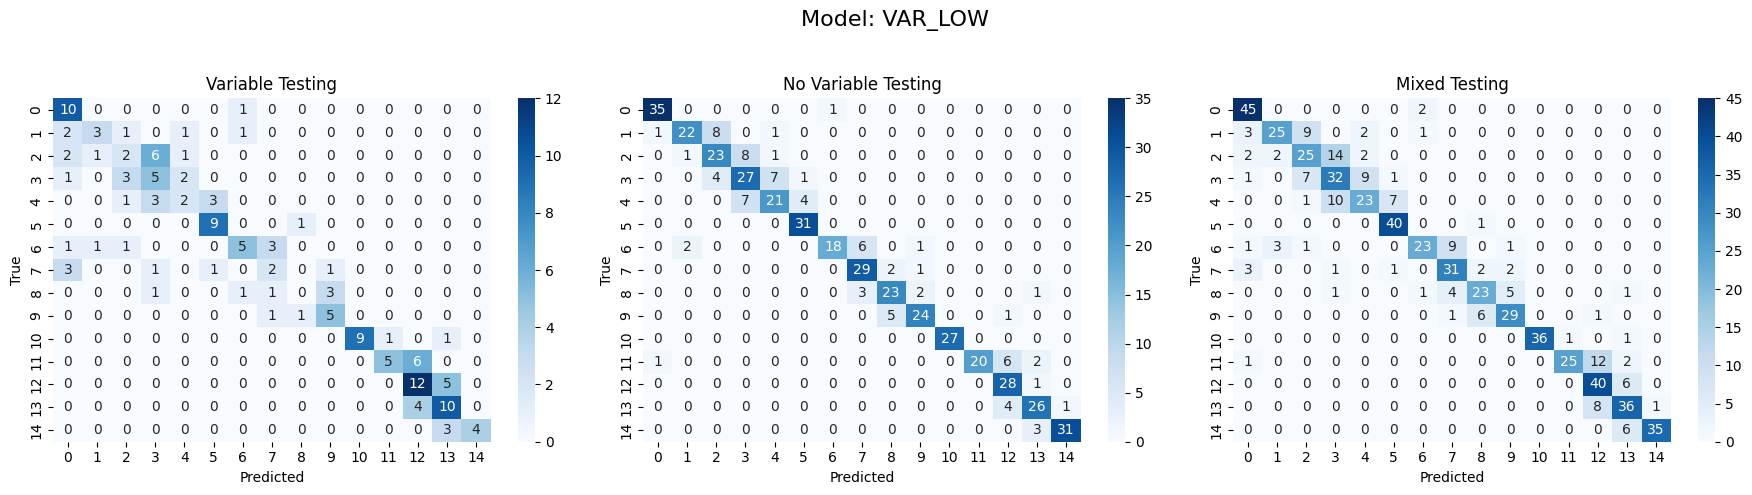

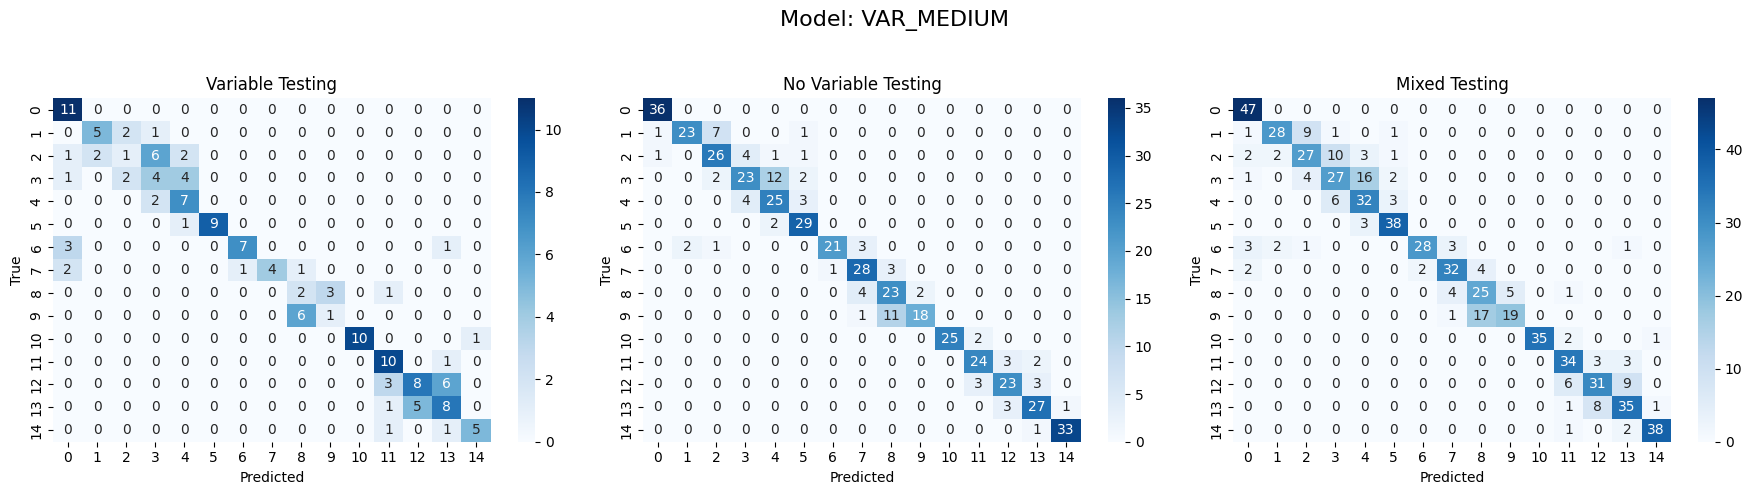

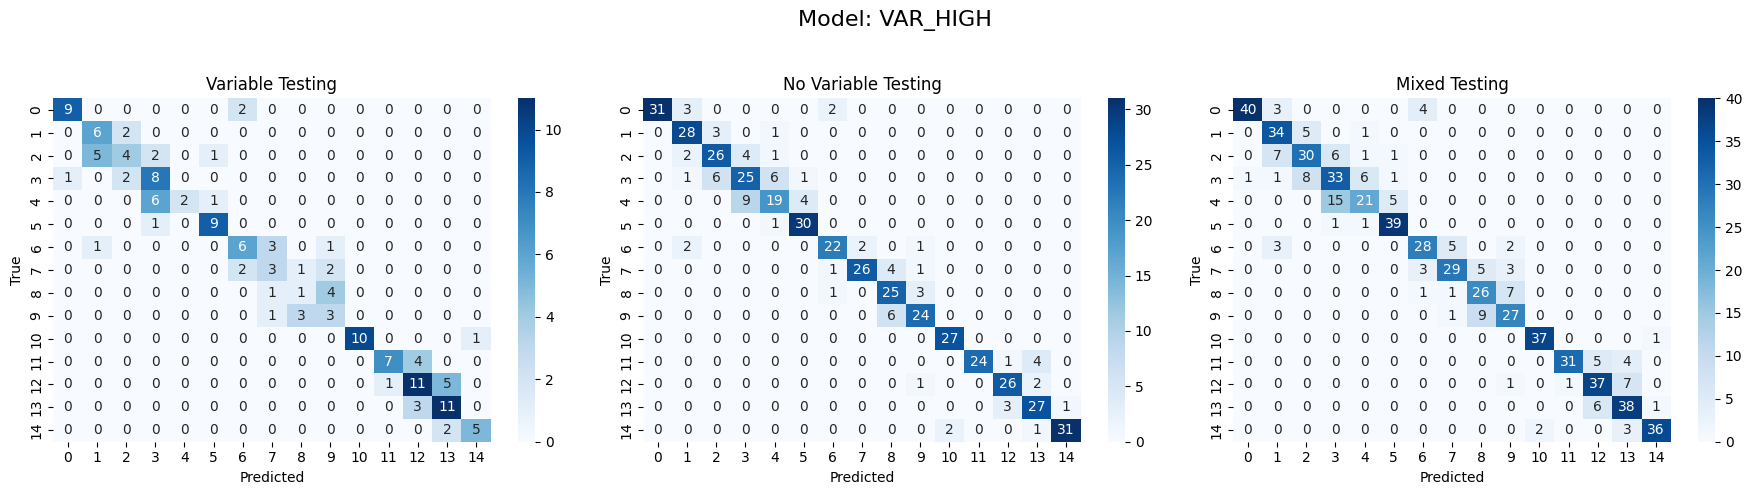

In [ ]:
def plot_confusion_matrices_row(cms, titles, suptitle):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, ax in enumerate(axes):
        sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(titles[i])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# VAR_LOW model
plot_confusion_matrices_row(
    [cm_var_low_var, cm_var_low_novar, cm_var_low_mixed],
    ["Variable Testing", "No Variable Testing", "Mixed Testing"],
    "Model: VAR_LOW"
)

# VAR_MEDIUM model
plot_confusion_matrices_row(
    [cm_var_medium_var, cm_var_medium_novar, cm_var_medium_mixed],
    ["Variable Testing", "No Variable Testing", "Mixed Testing"],
    "Model: VAR_MEDIUM"
)

# VAR_HIGH model
plot_confusion_matrices_row(
    [cm_var_high_var, cm_var_high_novar, cm_var_high_mixed],
    ["Variable Testing", "No Variable Testing", "Mixed Testing"],
    "Model: VAR_HIGH"
)


In [ ]:
print("Low Var - Var")
print(classification_report(pred_var_var_true, pred_var_low_var_labels))
print("Low Var - No Var")
print(classification_report(pred_var_novar_true, pred_var_low_novar_labels))
print("Low Var - Mixed")
print(classification_report(pred_var_mixed_true, pred_var_low_mixed_labels))
print("Medium Var - Var")
print(classification_report(pred_var_var_true, pred_var_medium_var_labels))
print("Medium Var - No Var")
print(classification_report(pred_var_novar_true, pred_var_medium_novar_labels))
print("Medium Var - Mixed")
print(classification_report(pred_var_mixed_true, pred_var_medium_mixed_labels))
print("High Var - Var")
print(classification_report(pred_var_var_true, pred_var_high_var_labels))
print("High Var - No Var")
print(classification_report(pred_var_novar_true, pred_var_high_novar_labels))
print("High Var - Mixed")
print(classification_report(pred_var_mixed_true, pred_var_high_mixed_labels))


Low Var - Var
              precision    recall  f1-score   support

           0       0.53      0.91      0.67        11
           1       0.60      0.38      0.46         8
           2       0.25      0.17      0.20        12
           3       0.31      0.45      0.37        11
           4       0.33      0.22      0.27         9
           5       0.69      0.90      0.78        10
           6       0.62      0.45      0.53        11
           7       0.29      0.25      0.27         8
           8       0.00      0.00      0.00         6
           9       0.56      0.71      0.62         7
          10       1.00      0.82      0.90        11
          11       0.83      0.45      0.59        11
          12       0.55      0.71      0.62        17
          13       0.53      0.71      0.61        14
          14       1.00      0.57      0.73         7

    accuracy                           0.54       153
   macro avg       0.54      0.51      0.51       153
weighted avg

In [ ]:
!pip install mediapipe==0.10.9

In [ ]:
# ALter image loader for mediapipe preprocessing

import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf

mp_hands = mp.solutions.hands

def load_image_mediapipe(image_path):
    # Recreate a new Hands object every time to avoid timestamp errors
    with mp.solutions.hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5) as hands:
        img = cv2.imread(os.path.join("AuslanStaticData", image_path.numpy().decode()))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)

        landmark_img = np.zeros_like(img_rgb)
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp.solutions.drawing_utils.draw_landmarks(
                    landmark_img,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp.solutions.drawing_utils.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=2),
                    mp.solutions.drawing_utils.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
                )

        landmark_img_tensor = tf.convert_to_tensor(landmark_img, dtype=tf.float32)
        landmark_img_tensor = tf.image.resize(landmark_img_tensor, [224, 224])
        landmark_img_tensor = landmark_img_tensor / 255.0
        return landmark_img_tensor


def load_image_wrapper_mediapipe(image_path):
    img = tf.py_function(load_image_mediapipe, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Create training datasets
no_variable_training_mediapipe = tf.data.Dataset.from_tensor_slices((training_images_without_var.values, label_training_no_var)) # Create a dataset from the paths and labels
no_variable_training_mediapipe = no_variable_training_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
no_variable_training_mediapipe = no_variable_training_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

variable_training_mediapipe = tf.data.Dataset.from_tensor_slices((training_images_with_var.values, label_training_var)) # Create a dataset from the paths and labels
variable_training_mediapipe = variable_training_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_training_mediapipe = variable_training_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

# Create testing datasets
validation_var_dataset_mediapipe = tf.data.Dataset.from_tensor_slices((validation_images_with_var.values, label_validation_var))  # Replace validation_labels with appropriate label data
validation_var_dataset_mediapipe = validation_var_dataset_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_var_dataset_mediapipe = validation_var_dataset_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE)

validation_no_var_dataset_mediapipe = tf.data.Dataset.from_tensor_slices((validation_images_without_var.values, label_validation_no_var))  # Replace validation_labels with appropriate label data
validation_no_var_dataset_mediapipe = validation_no_var_dataset_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation_no_var_dataset_mediapipe = validation_no_var_dataset_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE)

variable_testing_mediapipe = tf.data.Dataset.from_tensor_slices((testing_images_only_var.values, label_testing_var)) # Create a dataset from the paths and labels
variable_testing_mediapipe = variable_testing_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
variable_testing_mediapipe = variable_testing_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

mixed_testing_mediapipe = tf.data.Dataset.from_tensor_slices((testing_images_mixed.values, label_testing_mixed)) # Create a dataset from the paths and labels
mixed_testing_mediapipe = mixed_testing_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
mixed_testing_mediapipe = mixed_testing_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

no_variable_testing_mediapipe = tf.data.Dataset.from_tensor_slices((testing_images_without_var.values, label_testing_no_var)) # Create a dataset from the paths and labels
no_variable_testing_mediapipe = no_variable_testing_mediapipe.map(lambda image_path, label: (load_image_wrapper_mediapipe(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
no_variable_testing_mediapipe = no_variable_testing_mediapipe.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets
var_flip_dataset_mediapipe = variable_training_mediapipe.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument

no_var_flip_dataset_mediapipe = no_variable_training_mediapipe.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument

aug_no_var_training_mediapipe = tf.data.Dataset.sample_from_datasets([no_variable_training_mediapipe, no_var_flip_dataset_mediapipe])
aug_var_training_mediapipe = tf.data.Dataset.sample_from_datasets([variable_training_mediapipe, var_flip_dataset_mediapipe])

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 154s 301ms/step - accuracy: 0.0744 - loss: 3.8333
Epoch 2/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


456/456 ━━━━━━━━━━━━━━━━━━━━ 145s 315ms/step - accuracy: 0.0887 - loss: 3.7408
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 146s 317ms/step - accuracy: 0.1159 - loss: 3.6307
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 145s 315ms/step - accuracy: 0.1491 - loss: 3.4914
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 144s 313ms/step - accuracy: 0.2319 - loss: 3.2192
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 145s 313ms/step - accuracy: 0.3582 - loss: 2.8284
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 144s 313ms/step - accuracy: 0.5081 - loss: 2.3702
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 144s 314ms/step - accuracy: 0.6435 - loss: 1.9447
Epoch 9/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 146s 317ms/step - accuracy: 0.7641 - loss: 1.5802
Epoch 10/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 145s 315ms/step - accuracy: 0.8575 - loss: 1.2555


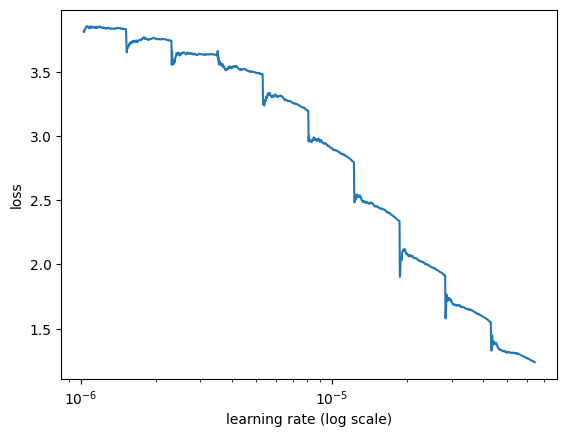

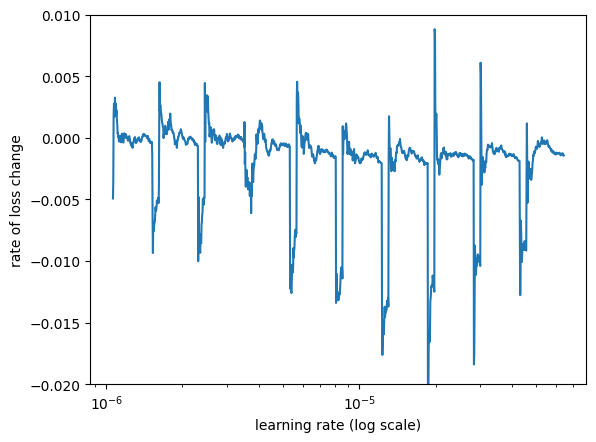

1.86668e-05


In [ ]:
# Find optimal learning rate

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model_mediapipe = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
# Unfreeze the last few convolutional layers
base_model_mediapipe.trainable = True

#Freeze most of the base model
for layer in base_model_mediapipe.layers[:-4]:
    layer.trainable = False

model_mediapipe = models.Sequential([
    base_model_mediapipe,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model_mediapipe.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

import numpy as np
K = tf.keras.backend

BATCH = 32



STEPS_PER_EPOCH = np.ceil(14585 / BATCH)
STEPS_PER_EPOCH = int(STEPS_PER_EPOCH)
lr_finder = LRFinder(model_mediapipe)
lr_finder.find_generator(aug_no_var_training_mediapipe, start_lr=1e-6, end_lr=1, epochs=10,
                         steps_per_epoch=STEPS_PER_EPOCH)

lr_finder.plot_loss()
lr_finder.plot_loss_change(sma=20, n_skip_beginning=20, n_skip_end=5, y_lim=(-0.02, 0.01))

best_lr_mediapipe = lr_finder.get_best_lr(sma=20)

# Setting it as our model's LR through Keras Backend
set_value(model.optimizer.learning_rate, best_lr_mediapipe)
print(best_lr_mediapipe)

In [ ]:
# Perform mediapipe experiments

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model_no_var_mediapipe = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_no_var_mediapipe.trainable = True

for layer in base_model_no_var_mediapipe.layers[:-4]:
    layer.trainable = False

model_no_var_mediapipe = models.Sequential([
    base_model_no_var_mediapipe,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate_mediapipe = float(best_lr_mediapipe)

optimizer_no_var_mediapipe = tf.keras.optimizers.Adam(learning_rate=learning_rate_mediapipe)

model_no_var_mediapipe.compile(
    optimizer=optimizer_no_var_mediapipe,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_no_var_mediapipe = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_no_var_mediapipe.fit(aug_no_var_training_mediapipe, epochs=50, batch_size=32,validation_data=validation_no_var_dataset_mediapipe, callbacks=[es_no_var_mediapipe])

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.0991 - loss: 3.6715 - val_accuracy: 0.2754 - val_loss: 3.2496
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.3138 - loss: 2.8763 - val_accuracy: 0.6589 - val_loss: 2.5812
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.5445 - loss: 2.2051 - val_accuracy: 0.7458 - val_loss: 1.9467
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.6807 - loss: 1.8286 - val_accuracy: 0.7924 - val_loss: 1.5476
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.7747 - loss: 1.5597 - val_accuracy: 0.8475 - val_loss: 1.3416
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.8337 - loss: 1.3709 - val_accuracy: 0.8708 - val_loss: 1.2182
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.8828 - loss: 1.2265 - val_accuracy: 0.8729 - val_loss: 1.1363
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9109 - loss: 1.1158 - val_accu

In [ ]:

base_model_var_mediapipe = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model_var_mediapipe.trainable = True

for layer in base_model_var_mediapipe.layers[:-4]:
    layer.trainable = False

model_var_mediapipe = models.Sequential([
    base_model_var_mediapipe,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

learning_rate_mediapipe = float(best_lr_mediapipe)

optimizer_var_mediapipe = tf.keras.optimizers.Adam(learning_rate=learning_rate_mediapipe)

model_var_mediapipe.compile(
    optimizer=optimizer_var_mediapipe,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_var_mediapipe = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
model_var_mediapipe.fit(aug_var_training_mediapipe, epochs=50, batch_size=32,validation_data=validation_var_dataset_mediapipe, callbacks=[es_var_mediapipe])

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.1106 - loss: 3.6012 - val_accuracy: 0.4361 - val_loss: 3.1374
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.3829 - loss: 2.6929 - val_accuracy: 0.6965 - val_loss: 2.2231
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.5802 - loss: 2.0693 - val_accuracy: 0.7971 - val_loss: 1.6167
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.7001 - loss: 1.7213 - val_accuracy: 0.8163 - val_loss: 1.3721
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7864 - loss: 1.4735 - val_accuracy: 0.8690 - val_loss: 1.2020
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.8328 - loss: 1.2977 - val_accuracy: 0.8882 - val_loss: 1.0926
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.8748 - loss: 1.1748 - val_accuracy: 0.8994 - val_loss: 1.0321
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.9005 - loss: 1.0698 - val_accu

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_var_var = model_var_mediapipe.predict(variable_testing_mediapipe, verbose=1)
pred_var_novar = model_var_mediapipe.predict(no_variable_testing_mediapipe, verbose=1)
pred_var_mixed = model_var_mediapipe.predict(mixed_testing_mediapipe, verbose=1)

pred_novar_var = model_no_var_mediapipe.predict(variable_testing_mediapipe, verbose=1)
pred_novar_novar = model_no_var_mediapipe.predict(no_variable_testing_mediapipe, verbose=1)
pred_novar_mixed = model_no_var_mediapipe.predict(mixed_testing_mediapipe, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_var_var_labels = np.argmax(pred_var_var, axis=1)
pred_var_novar_labels = np.argmax(pred_var_novar, axis=1)
pred_var_mixed_labels = np.argmax(pred_var_mixed, axis=1)
pred_novar_var_labels = np.argmax(pred_novar_var, axis=1)
pred_novar_novar_labels = np.argmax(pred_novar_novar, axis=1)
pred_novar_mixed_labels = np.argmax(pred_novar_mixed, axis=1)

# Get the true labels from the test set generator
pred_var_var_true = np.concatenate([y.numpy() for _, y in variable_testing_mediapipe.unbatch()])
pred_var_novar_true = np.concatenate([y.numpy() for _, y in no_variable_testing_mediapipe.unbatch()])
pred_var_mixed_true = np.concatenate([y.numpy() for _, y in mixed_testing_mediapipe.unbatch()])

pred_novar_var_true = np.concatenate([y.numpy() for _, y in variable_testing_mediapipe.unbatch()])
pred_novar_novar_true = np.concatenate([y.numpy() for _, y in no_variable_testing_mediapipe.unbatch()])
pred_novar_mixed_true = np.concatenate([y.numpy() for _, y in mixed_testing_mediapipe.unbatch()])

# Reshape into (N, 36) where N is inferred
pred_var_var_true = pred_var_var_true.reshape(-1, 15)
pred_var_novar_true = pred_var_novar_true.reshape(-1, 15)
pred_var_mixed_true = pred_var_mixed_true.reshape(-1, 15)
pred_novar_var_true = pred_novar_var_true.reshape(-1, 15)
pred_novar_novar_true = pred_novar_novar_true.reshape(-1, 15)
pred_novar_mixed_true = pred_novar_mixed_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_var_var_true = np.argmax(pred_var_var_true, axis=1)
pred_var_novar_true = np.argmax(pred_var_novar_true, axis=1)
pred_var_mixed_true = np.argmax(pred_var_mixed_true, axis=1)
pred_novar_var_true = np.argmax(pred_novar_var_true, axis=1)
pred_novar_novar_true = np.argmax(pred_novar_novar_true, axis=1)
pred_novar_mixed_true = np.argmax(pred_novar_mixed_true, axis=1)

# Generate the confusion matrix
cm_var_var = confusion_matrix(pred_var_var_true, pred_var_var_labels)
cm_var_novar = confusion_matrix(pred_var_novar_true, pred_var_novar_labels)
cm_var_mixed = confusion_matrix(pred_var_mixed_true, pred_var_mixed_labels)
cm_novar_var = confusion_matrix(pred_novar_var_true, pred_novar_var_labels)
cm_novar_novar = confusion_matrix(pred_novar_novar_true, pred_novar_novar_labels)
cm_novar_mixed = confusion_matrix(pred_novar_mixed_true, pred_novar_mixed_labels)

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


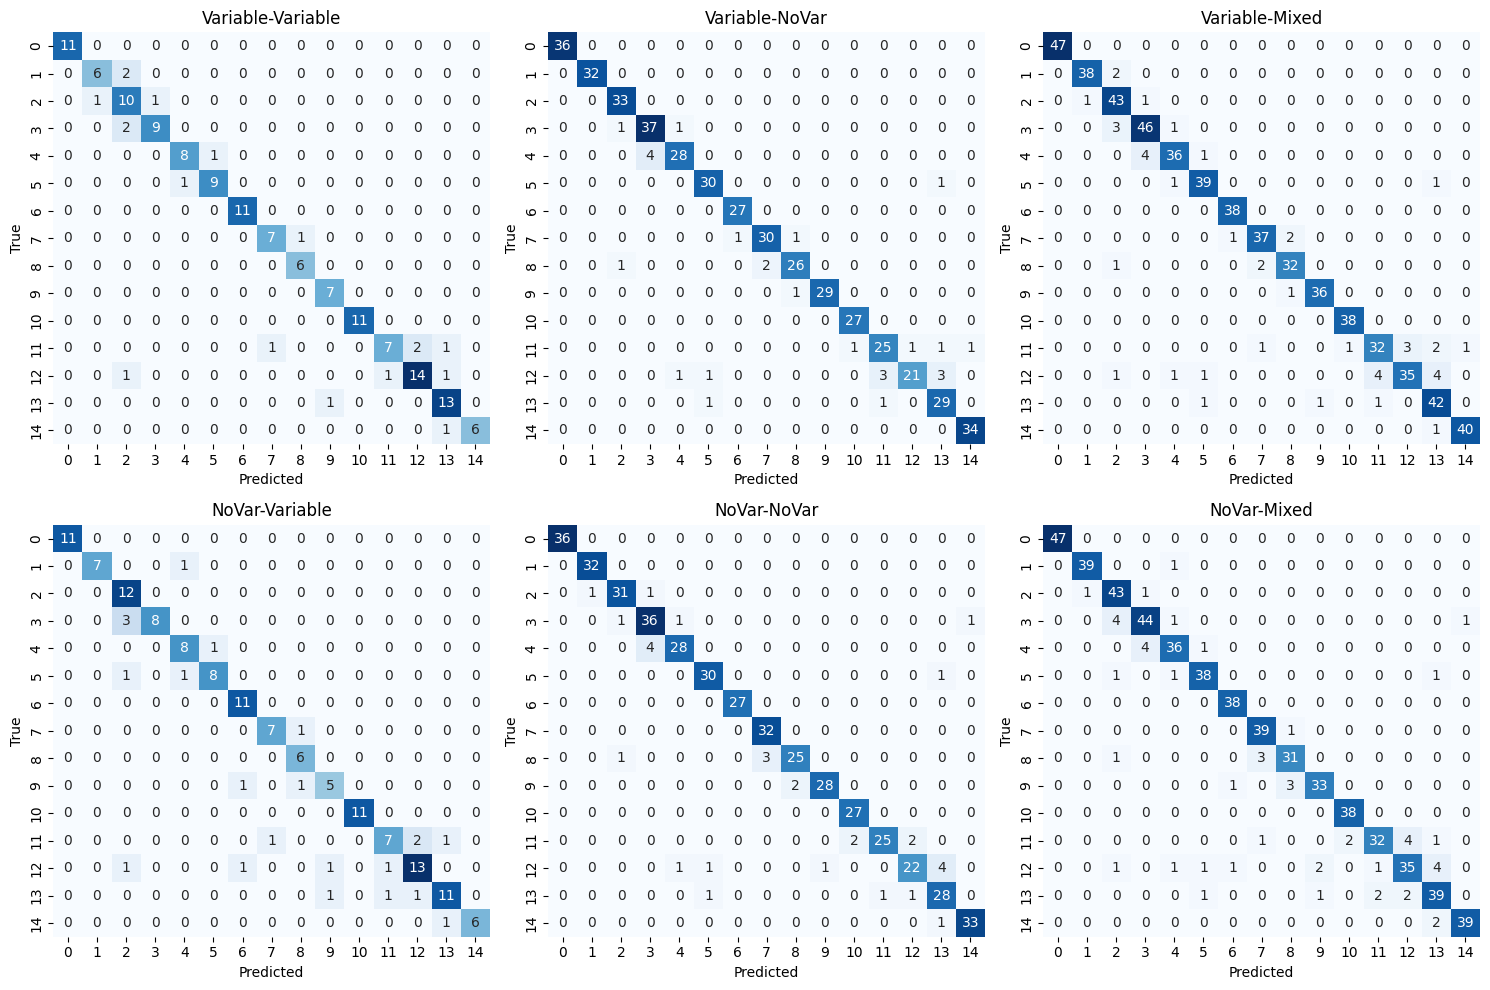

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_var_var, cm_var_novar, cm_var_mixed,
                      cm_novar_var, cm_novar_novar, cm_novar_mixed]
titles = ['Variable-Variable', 'Variable-NoVar', 'Variable-Mixed',
          'NoVar-Variable', 'NoVar-NoVar', 'NoVar-Mixed']

# Create a 2x3 grid for plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Loop over each subplot and confusion matrix to plot
for ax, cm, title in zip(axes.flatten(), confusion_matrices, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=[str(i) for i in range(cm.shape[1])],
                yticklabels=[str(i) for i in range(cm.shape[0])])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print("Var - Var")
print(classification_report(pred_var_var_true, pred_var_var_labels))
print("Var - No Var")
print(classification_report(pred_var_novar_true, pred_var_novar_labels))
print("Var - Mixed")
print(classification_report(pred_var_mixed_true, pred_var_mixed_labels))
print("No Var - Var")
print(classification_report(pred_novar_var_true, pred_novar_var_labels))
print("No Var - No Var")
print(classification_report(pred_novar_novar_true, pred_novar_novar_labels))
print("No Var - Mixed")
print(classification_report(pred_novar_mixed_true, pred_novar_mixed_labels))

Var - Var
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.86      0.75      0.80         8
           2       0.67      0.83      0.74        12
           3       0.90      0.82      0.86        11
           4       0.89      0.89      0.89         9
           5       0.90      0.90      0.90        10
           6       1.00      1.00      1.00        11
           7       0.88      0.88      0.88         8
           8       0.86      1.00      0.92         6
           9       0.88      1.00      0.93         7
          10       1.00      1.00      1.00        11
          11       0.88      0.64      0.74        11
          12       0.88      0.82      0.85        17
          13       0.81      0.93      0.87        14
          14       1.00      0.86      0.92         7

    accuracy                           0.88       153
   macro avg       0.89      0.89      0.89       153
weighted avg    

In [ ]:
import sys
import tensorflow as tf
import pandas as pd
import numpy as np
import mediapipe as mp
import gspread
import matplotlib
import seaborn
import sklearn

print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Mediapipe version: {mp.__version__}")
print(f"gspread version: {gspread.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {seaborn.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
TensorFlow version: 2.18.0
Pandas version: 2.2.2
NumPy version: 2.0.2
Mediapipe version: 0.10.9
gspread version: 6.2.0
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1


In [ ]:
from google.colab import runtime
runtime.unassign()